<a href="https://colab.research.google.com/github/Deepikadandolu/SumInt_IISc_ex1/blob/main/chest_svm(linear)_split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


In [ ]:
# Define classes and labels
classes = {
    'NORMAL': 0,
    'PNEUMONIA': 1}

# Dataset training folder path
train_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'

# Load and preprocess dataset
X = []
Y = []

for cls, label in classes.items():
    class_path = os.path.join(train_path, cls)
    for filename in os.listdir(class_path):
        img_path = os.path.join(class_path, filename)
        # Read image in grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            # Resize image
            img = cv2.resize(img, (200, 200))
            # Normalize image
            img = img / 255.0
            # Flatten image
            X.append(img.flatten())
            # Append label
            Y.append(label)
# Convert to numpy arrays
X = np.array(X)
Y = np.array(Y)

print("Dataset loaded successfully")
print("X shape:", X.shape)
print("Y shape:", Y.shape)

Dataset loaded successfully
X shape: (5216, 40000)
Y shape: (5216,)


In [ ]:
# Split the dataset into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=42,
    test_size=0.2,
    stratify=Y)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.98)
pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

print("Original shape:", xtrain.shape)
print("PCA reduced shape:", pca_train.shape)

# Train Support Vector Classifier with LINEAR kernel
sv = SVC(kernel='linear')
sv.fit(pca_train, ytrain)

# Evaluate the model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)

print("\nLinear SVM Results")
print("20-80 Split")
print("Training Score:", train_score)
print("Testing Score:", test_score)

Original shape: (4172, 40000)
PCA reduced shape: (4172, 1523)

Linear SVM Results
20-80 Split
Training Score: 1.0
Testing Score: 0.9482758620689655


In [ ]:
# Split the dataset 40-60
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=42,
    test_size=0.6,
    stratify=Y)
print("Training Data Shape :", xtrain.shape)
print("Testing Data Shape  :", xtest.shape)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.98)
pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)
print("PCA Reduced Training Shape :", pca_train.shape)
print("PCA Reduced Testing Shape  :", pca_test.shape)

# Train Support Vector Classifier with LINEAR kernel
sv = SVC(kernel='linear')
sv.fit(pca_train, ytrain)

# Evaluate the model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)

print("\n40-60 Split")
print("\nLinear SVM Results")
print("Training Score :", train_score)
print("Testing Score  :", test_score)

Training Data Shape : (2086, 40000)
Testing Data Shape  : (3130, 40000)
PCA Reduced Training Shape : (2086, 976)
PCA Reduced Testing Shape  : (3130, 976)

40-60 Split

Linear SVM Results
Training Score : 1.0
Testing Score  : 0.9539936102236422


In [ ]:
# Split the dataset into 60-40
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=42,
    test_size=0.4,
    stratify=Y
)

print("Training Data Shape :", xtrain.shape)
print("Testing Data Shape  :", xtest.shape)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.98)

pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

print("PCA Reduced Training Shape :", pca_train.shape)
print("PCA Reduced Testing Shape  :", pca_test.shape)

# Train Support Vector Classifier with LINEAR kernel
sv = SVC(kernel='linear')

sv.fit(pca_train, ytrain)

# Evaluate the model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)

print("\n60-40 Split")
print("\nLinear SVM Results")
print("Training Score :", train_score)
print("Testing Score  :", test_score)

Training Data Shape : (3129, 40000)
Testing Data Shape  : (2087, 40000)
PCA Reduced Training Shape : (3129, 1277)
PCA Reduced Testing Shape  : (2087, 1277)

60-40 Split

Linear SVM Results
Training Score : 1.0
Testing Score  : 0.9535218016291327


In [ ]:
# Split the dataset into 80-20
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=42,
    test_size=0.2,
    stratify=Y
)

print("Training Data Shape :", xtrain.shape)
print("Testing Data Shape  :", xtest.shape)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.98)

pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

print("PCA Reduced Training Shape :", pca_train.shape)
print("PCA Reduced Testing Shape  :", pca_test.shape)

# Train Support Vector Classifier with LINEAR kernel
sv = SVC(kernel='linear')

sv.fit(pca_train, ytrain)

# Evaluate the model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)

print("\n80-20 Split")
print("\nLinear SVM Results")
print("Training Score :", train_score)
print("Testing Score  :", test_score)

In [ ]:
# Display sample images and predictions
def display_samples(folder, title, model, pca, num_samples=9):
    plt.figure(figsize=(12, 8))
    c = 1
    for filename in os.listdir(folder)[:num_samples]:
        img_path = os.path.join(folder, filename)
        # Read image in grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            # Resize image
            img = cv2.resize(img, (200, 200))
            # Normalize and flatten
            img_flat = img.flatten() / 255.0
            # Apply PCA
            img_pca = pca.transform([img_flat])
            # Predict
            prediction = model.predict(img_pca)
            # Label names
            predicted_label = "NORMAL" if prediction[0] == 0 else "PNEUMONIA"
            # Display image
            plt.subplot(3, 3, c)
            plt.title(predicted_label)
            plt.imshow(img, cmap='gray')
            plt.axis('off')
            c += 1
    plt.suptitle(title)
    plt.show()


Predictions using LINEAR SVM - 20-80 Split


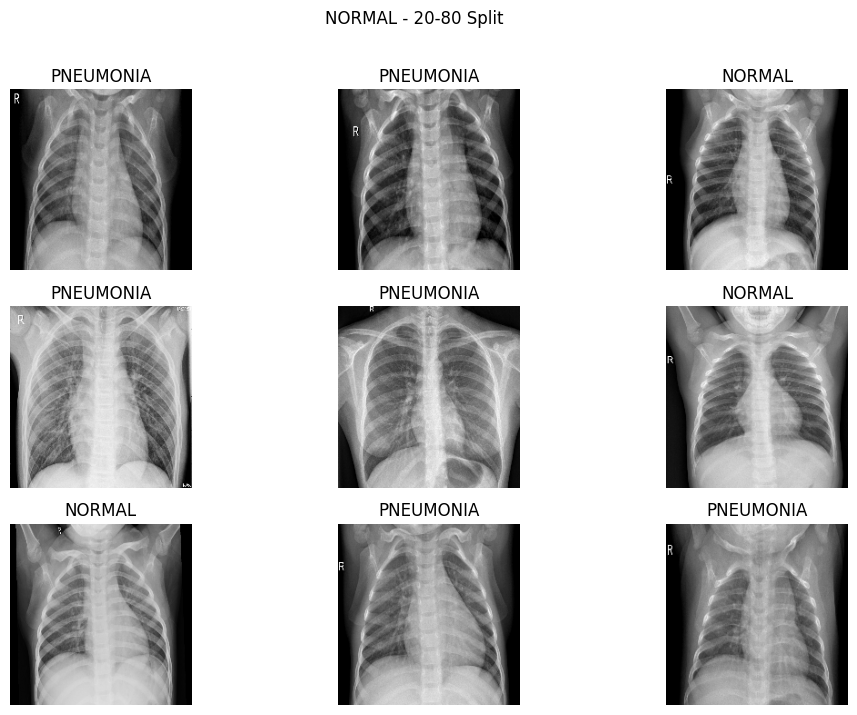

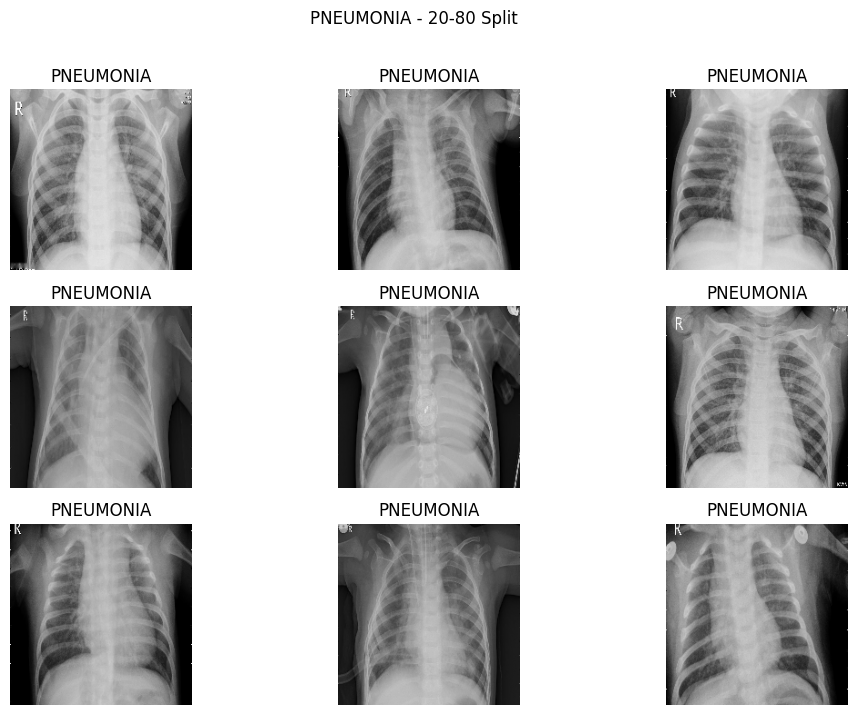


Predictions using LINEAR SVM - 40-60 Split


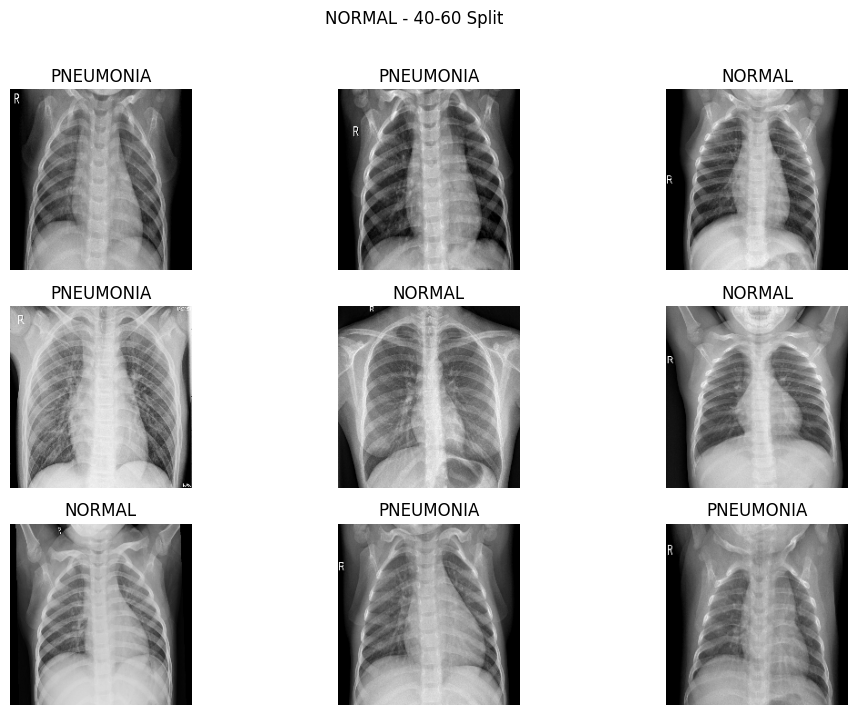

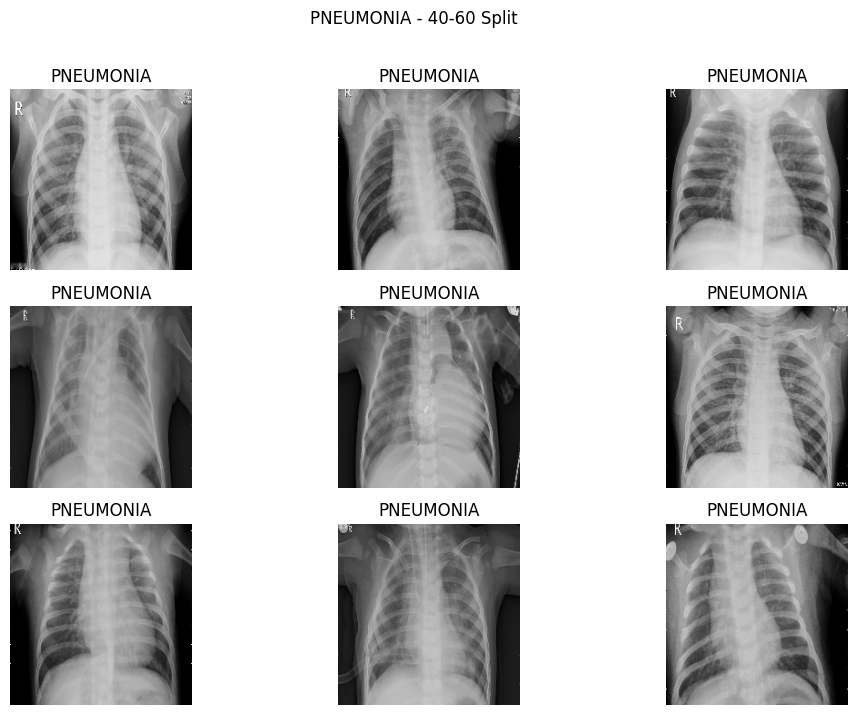


Predictions using LINEAR SVM - 60-40 Split


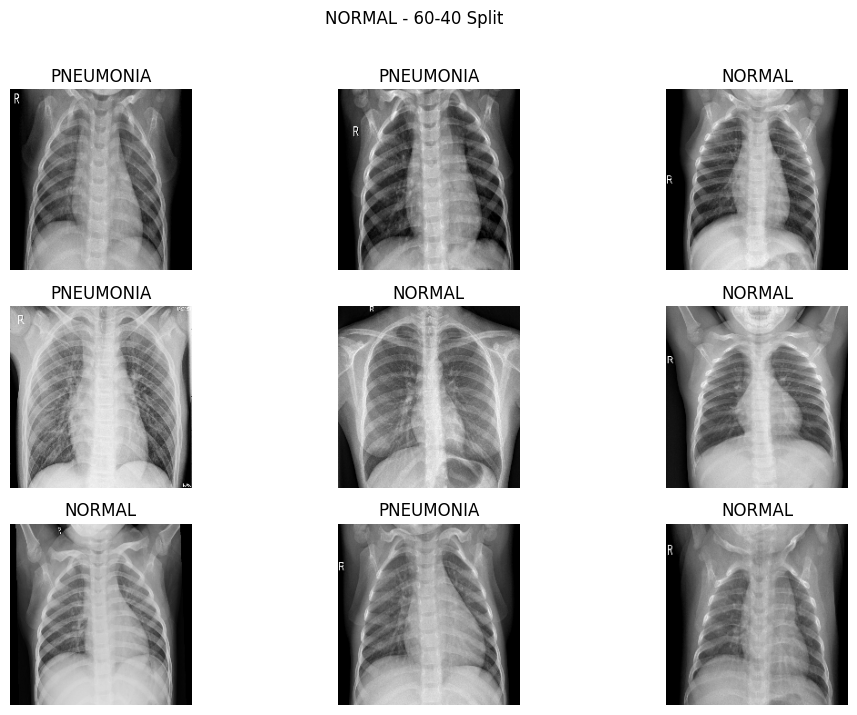

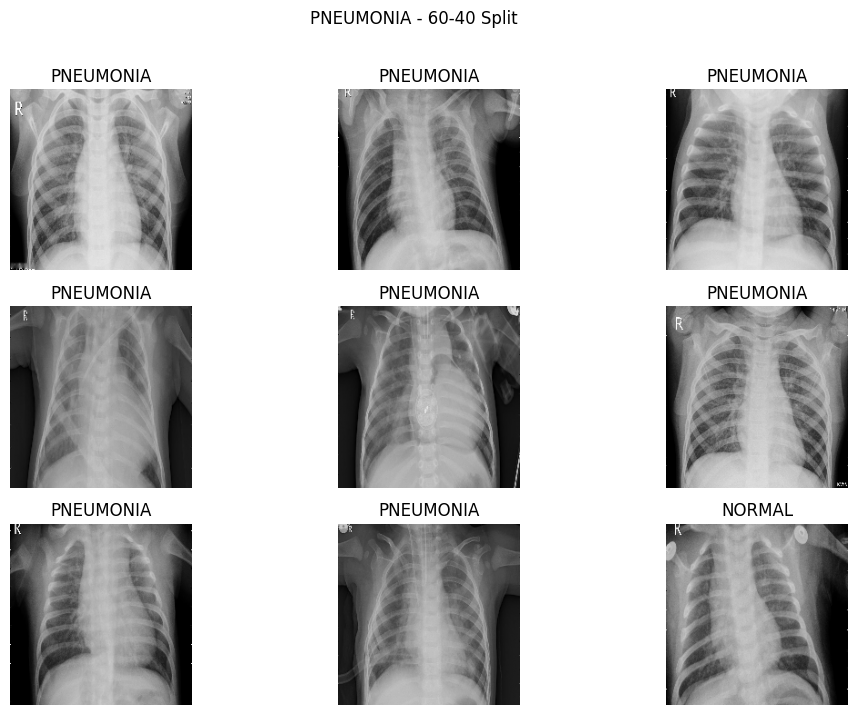


Predictions using LINEAR SVM - 80-20 Split


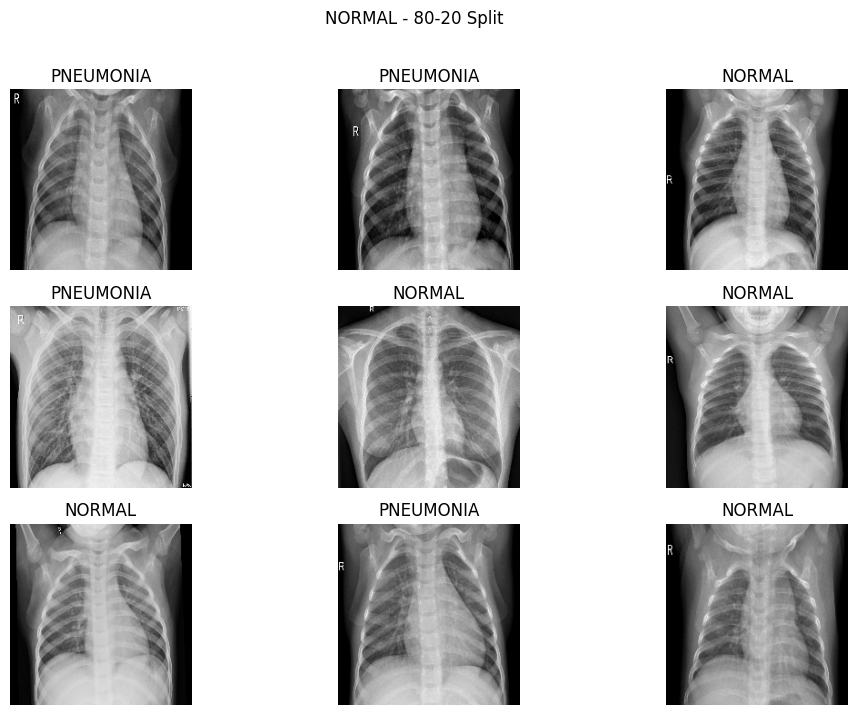

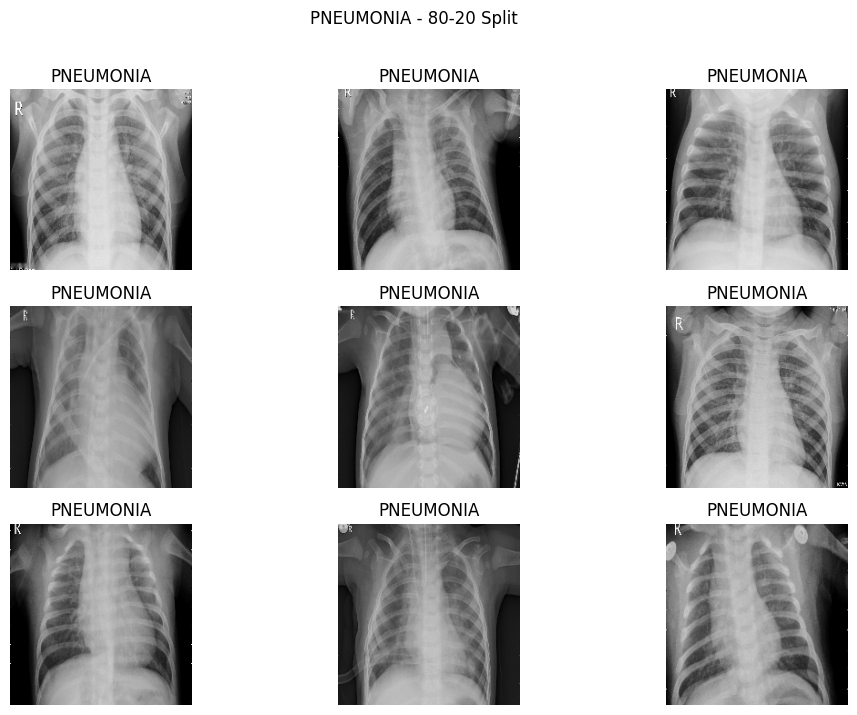

In [ ]:
# Define class labels
dec = {
    0: 'NORMAL',
    1: 'PNEUMONIA'}

# Get testing dataset path
test_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/test'
# Different train-test splits
splits = {
    "20-80 Split": 0.8,
    "40-60 Split": 0.6,
    "60-40 Split": 0.4,
    "80-20 Split": 0.2}

# Chest X-ray folders
xray_folders = [
    'NORMAL',
    'PNEUMONIA']
for split_name, test_size in splits.items():
    # Split dataset
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        random_state=42,
        test_size=test_size,
        stratify=Y)
    # Apply PCA
    pca = PCA(n_components=0.98)
    pca_train = pca.fit_transform(xtrain)
    pca_test = pca.transform(xtest)
    # Train Linear SVM
    sv = SVC(kernel='linear')
    sv.fit(pca_train, ytrain)
    print(f"\nPredictions using LINEAR SVM - {split_name}")
    # Display predictions
    for xray_folder in xray_folders:
        folder_path = os.path.join(test_path, xray_folder)
        title = f'{xray_folder} - {split_name}'
        display_samples(folder_path, title, sv, pca)

In [ ]:
import pandas as pd

# Different train-test splits
splits = {
    "20-80 Split": 0.8,
    "40-60 Split": 0.6,
    "60-40 Split": 0.4,
    "80-20 Split": 0.2}
for split_name, test_size in splits.items():
    # Split dataset
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        random_state=42,
        test_size=test_size,
        stratify=Y )
    # Count class samples in training data
    xray_counts = {
        dec[label]: np.sum(ytrain == label)
        for label in classes.values()}
    # Create table
    table_data = {
        'Index': range(1, len(classes) + 1),
        'Chest X-Ray Class': list(xray_counts.keys()),
        'Count': list(xray_counts.values())}
    xray_table = pd.DataFrame(table_data)
    # Style table
    styled_table = xray_table.style.set_properties(
        **{
            'border': '3px solid black',
            'text-align': 'center'  })
    print(f"\nChest X-Ray Class Counts - {split_name}")
    display(styled_table)


Chest X-Ray Class Counts - 20-80 Split


,Index,Chest X-Ray Class,Count
0,1,NORMAL,268
1,2,PNEUMONIA,775



Chest X-Ray Class Counts - 40-60 Split


,Index,Chest X-Ray Class,Count
0,1,NORMAL,536
1,2,PNEUMONIA,1550



Chest X-Ray Class Counts - 60-40 Split


,Index,Chest X-Ray Class,Count
0,1,NORMAL,804
1,2,PNEUMONIA,2325



Chest X-Ray Class Counts - 80-20 Split


,Index,Chest X-Ray Class,Count
0,1,NORMAL,1073
1,2,PNEUMONIA,3099


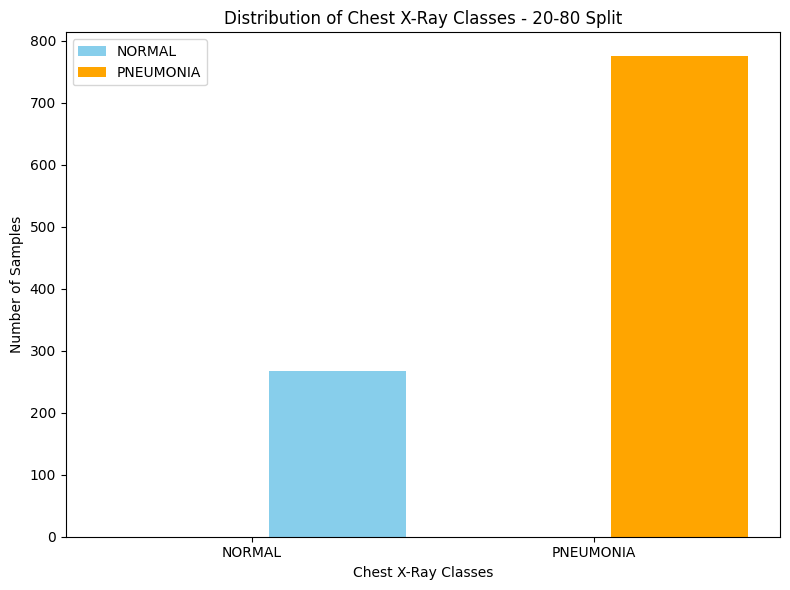

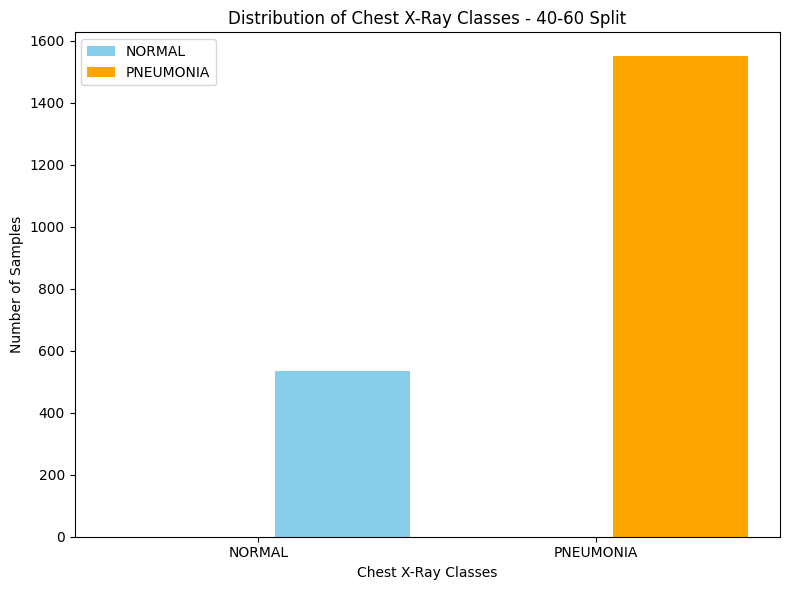

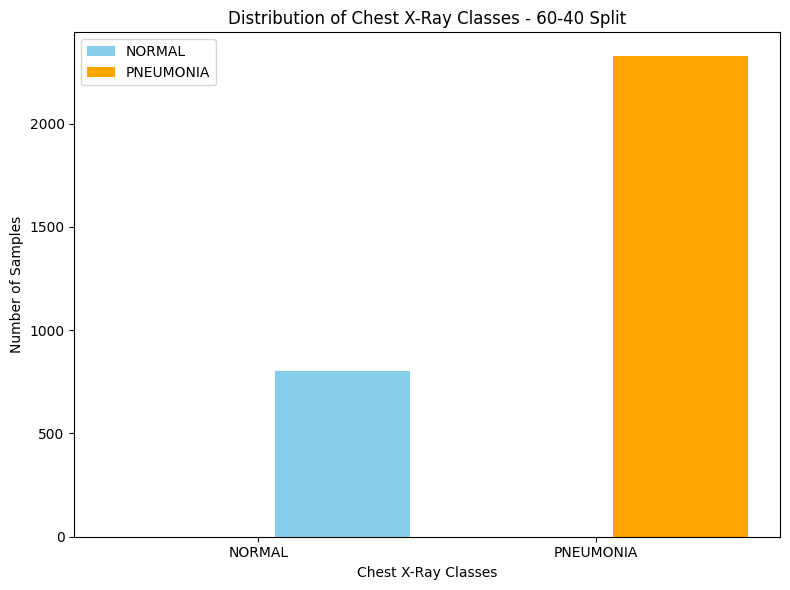

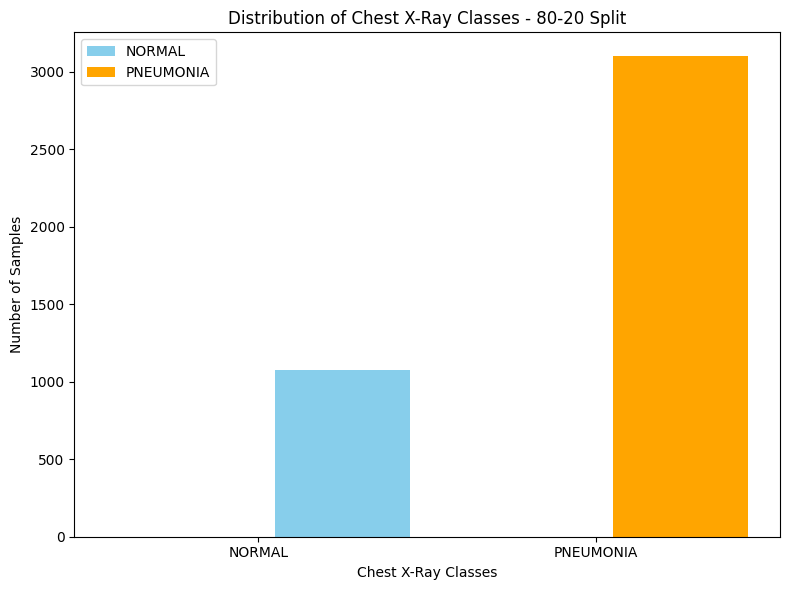

In [ ]:
# Create histogram of Chest X-ray classes for different train-test splits

colors = ['skyblue', 'orange']

splits = {
    "20-80 Split": 0.8,
    "40-60 Split": 0.6,
    "60-40 Split": 0.4,
    "80-20 Split": 0.2
}

for split_name, test_size in splits.items():

    # Split dataset
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        random_state=42,
        test_size=test_size,
        stratify=Y
    )

    # Convert labels to class names
    xray_labels = [dec[label] for label in ytrain]

    plt.figure(figsize=(8, 6))

    for label, color in zip(classes.values(), colors):

        plt.hist(
            np.array(xray_labels)[ytrain == label],
            bins=len(classes),
            align='mid',
            rwidth=0.8,
            color=color,
            label=dec[label]
        )

    plt.xlabel('Chest X-Ray Classes')
    plt.ylabel('Number of Samples')
    plt.title(f'Distribution of Chest X-Ray Classes - {split_name}')

    plt.xticks(
        range(len(classes)),
        list(classes.keys()),
        rotation=0
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix
)
train_sizes = [0.2, 0.4, 0.6, 0.8]
for train_size in train_sizes:
    # Split dataset
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        train_size=train_size,
        random_state=42,
        stratify=Y)
    print(f"\nTraining Size : {int(train_size * 100)}%")
    print("Training Shape:", xtrain.shape)
    print("Testing Shape :", xtest.shape)
    # Apply PCA
    pca = PCA(n_components=0.98)
    pca_train = pca.fit_transform(xtrain)
    pca_test = pca.transform(xtest)
    print("PCA Training Shape:", pca_train.shape)
    print("PCA Testing Shape :", pca_test.shape)
    # Train Linear SVM
    svm_linear = SVC(kernel='linear')
    svm_linear.fit(pca_train, ytrain)
    # Predictions
    ypred_linear = svm_linear.predict(pca_test)
    # Metrics
    accuracy_linear = accuracy_score(
        ytest,
        ypred_linear)
    f1_linear = f1_score(
        ytest,
        ypred_linear,
        average='weighted')
    cm_linear = confusion_matrix(
        ytest,
        ypred_linear)
    sensitivity_linear = np.mean(
        cm_linear.diagonal() / cm_linear.sum(axis=1))
    specificity_linear = np.mean([
        (
            np.sum(cm_linear) -
            (
                cm_linear[i, :].sum() +
                cm_linear[:, i].sum() -
                cm_linear[i, i])) /
        (np.sum(cm_linear) -
          cm_linear[i, :].sum())
        for i in range(len(cm_linear))
    ])
    print(f"\nLinear SVM Results ({int(train_size*100)}-{int((1-train_size)*100)} Split)")
    print("Accuracy   :", accuracy_linear)
    print("F1-Score   :", f1_linear)
    print("Sensitivity:", sensitivity_linear)
    print("Specificity:", specificity_linear)


Training Size : 20%
Training Shape: (1043, 40000)
Testing Shape : (4173, 40000)
PCA Training Shape: (1043, 594)
PCA Testing Shape : (4173, 594)

Linear SVM Results (20-80 Split)
Accuracy   : 0.9513539420081476
F1-Score   : 0.950780466046371
Sensitivity: 0.9252104440369179
Specificity: 0.9252104440369179

Training Size : 40%
Training Shape: (2086, 40000)
Testing Shape : (3130, 40000)
PCA Training Shape: (2086, 976)
PCA Testing Shape : (3130, 976)

Linear SVM Results (40-60 Split)
Accuracy   : 0.9539936102236422
F1-Score   : 0.9537042970779374
Sensitivity: 0.9337046684031256
Specificity: 0.9337046684031256

Training Size : 60%
Training Shape: (3129, 40000)
Testing Shape : (2087, 40000)
PCA Training Shape: (3129, 1277)
PCA Testing Shape : (2087, 1277)

Linear SVM Results (60-40 Split)
Accuracy   : 0.9535218016291327
F1-Score   : 0.9532747864499224
Sensitivity: 0.9340241484952243
Specificity: 0.9340241484952243

Training Size : 80%
Training Shape: (4172, 40000)
Testing Shape : (1044, 4000

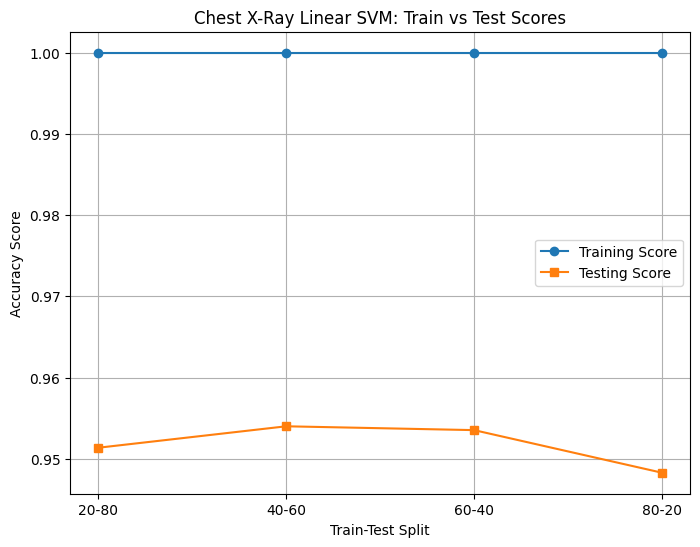

In [ ]:
train_sizes = [0.2, 0.4, 0.6, 0.8]
split_labels = ['20-80', '40-60', '60-40', '80-20']
train_scores = []
test_scores = []
for train_size in train_sizes:
    # Split dataset
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        train_size=train_size,
        random_state=42,
        stratify=Y)

    # Apply PCA
    pca = PCA(n_components=0.98)
    pca_train = pca.fit_transform(xtrain)
    pca_test = pca.transform(xtest)
    # Train Linear SVM
    sv = SVC(kernel='linear')
    sv.fit(pca_train, ytrain)
    # Scores
    train_score = sv.score(pca_train, ytrain)
    test_score = sv.score(pca_test, ytest)
    train_scores.append(train_score)
    test_scores.append(test_score)

# Plot graph
plt.figure(figsize=(8, 6))
plt.plot(
    split_labels,
    train_scores,
    marker='o',
    label='Training Score')
plt.plot(
    split_labels,
    test_scores,
    marker='s',
    label='Testing Score')
plt.xlabel('Train-Test Split')
plt.ylabel('Accuracy Score')
plt.title('Chest X-Ray Linear SVM: Train vs Test Scores')
plt.legend()
plt.grid(True)
plt.show()